In [45]:
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Display settings
pd.set_option('display.max_columns', None)
sns.set(style="whitegrid")

# ✅ Load the cleaned dataset
df = pd.read_csv(
    r"C:\Users\Dell\OneDrive\Documents\Projects\sales_dashboard_superstore\data\clean\superstore_clean.csv",
    encoding='latin1',
    parse_dates=['Order Date', 'Ship Date']
)

print("Shape:", df.shape)
df.head()


Shape: (9994, 27)


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Year,Month,YearMonth,Profit_Margin,Processing_Days,Sales_per_Unit
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136,2016,11,2016-11,0.1600,3,130.9800
1,2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820,2016,11,2016-11,0.3000,3,243.9800
2,3,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714,2016,6,2016-06,0.4700,4,7.3100
3,4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310,2015,10,2015-10,-0.4000,7,191.5155
4,5,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164,2015,10,2015-10,0.1125,7,11.1840


In [41]:
# Quick info and stats
df.info()
df.describe()

# Check for nulls
print("\nMissing values:\n", df.isnull().sum())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 27 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   Row ID           9994 non-null   int64         
 1   Order ID         9994 non-null   object        
 2   Order Date       9994 non-null   datetime64[ns]
 3   Ship Date        9994 non-null   datetime64[ns]
 4   Ship Mode        9994 non-null   object        
 5   Customer ID      9994 non-null   object        
 6   Customer Name    9994 non-null   object        
 7   Segment          9994 non-null   object        
 8   Country          9994 non-null   object        
 9   City             9994 non-null   object        
 10  State            9994 non-null   object        
 11  Postal Code      9994 non-null   int64         
 12  Region           9994 non-null   object        
 13  Product ID       9994 non-null   object        
 14  Category         9994 non-null   object 

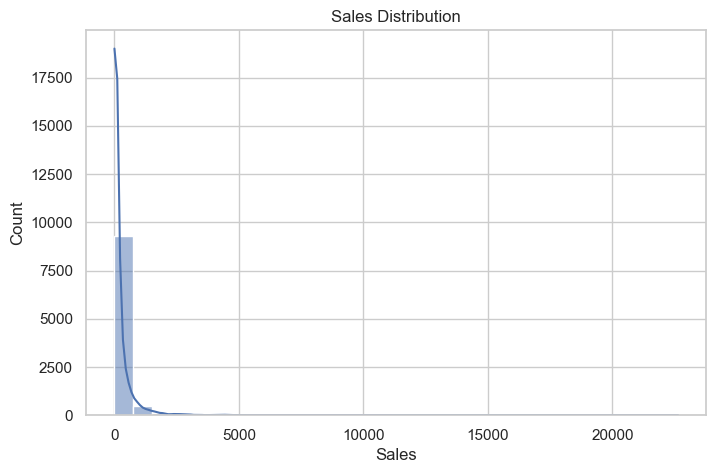

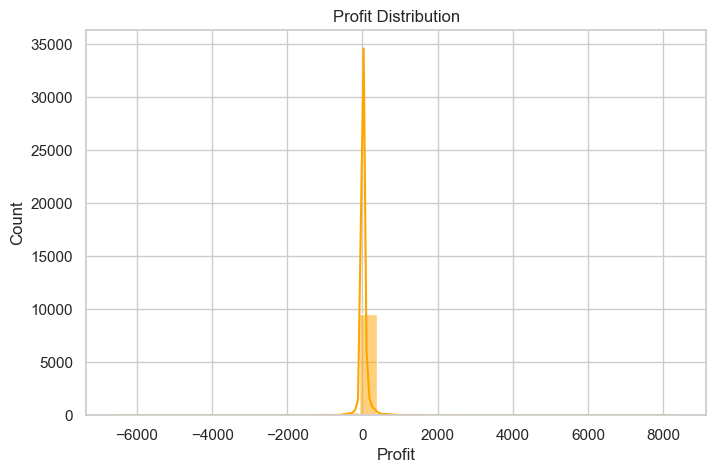

In [43]:
plt.figure(figsize=(8,5))
sns.histplot(df['Sales'], bins=30, kde=True)
plt.title("Sales Distribution")
plt.show()

plt.figure(figsize=(8,5))
sns.histplot(df['Profit'], bins=30, kde=True, color='orange')
plt.title("Profit Distribution")
plt.show()


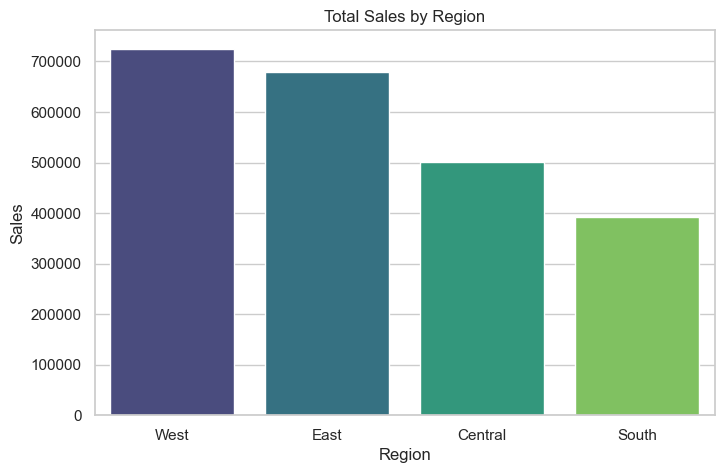

In [24]:
region_sales = df.groupby('Region')['Sales'].sum().sort_values(ascending=False)

plt.figure(figsize=(8,5))
sns.barplot(x=region_sales.index, y=region_sales.values, palette="viridis")
plt.title("Total Sales by Region")
plt.ylabel("Sales")
plt.xlabel("Region")
plt.show()


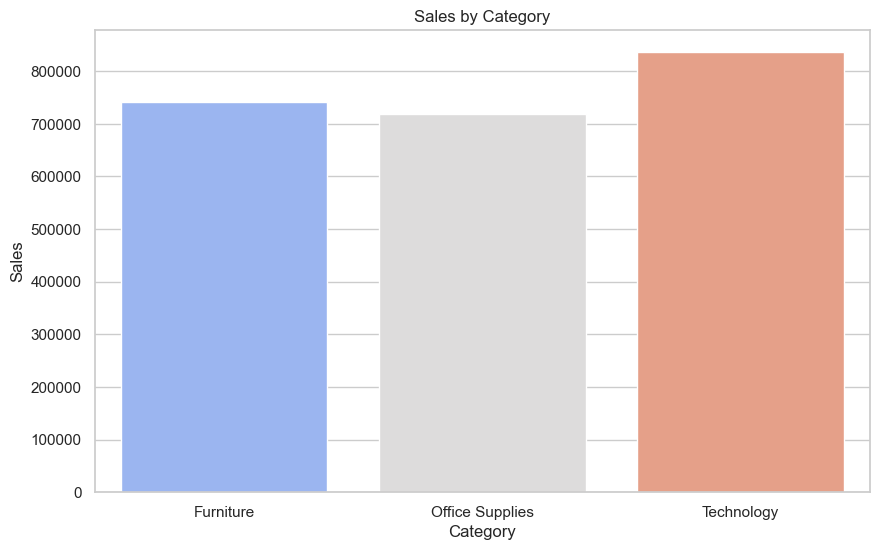

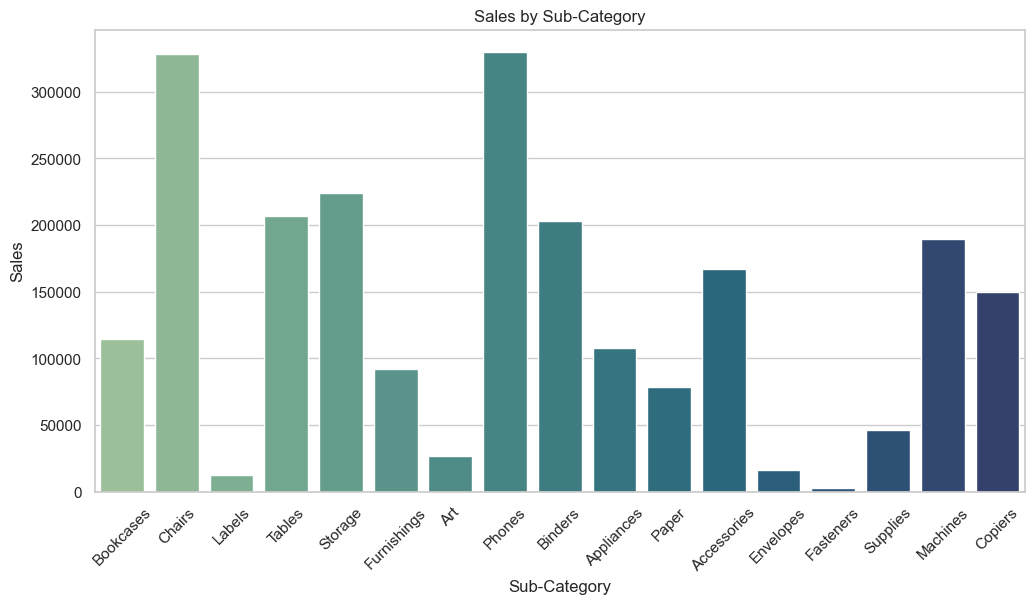

In [25]:
plt.figure(figsize=(10,6))
sns.barplot(x='Category', y='Sales', data=df, estimator=sum, ci=None, palette='coolwarm')
plt.title("Sales by Category")
plt.show()

plt.figure(figsize=(12,6))
sns.barplot(x='Sub-Category', y='Sales', data=df, estimator=sum, ci=None, palette='crest')
plt.title("Sales by Sub-Category")
plt.xticks(rotation=45)
plt.show()


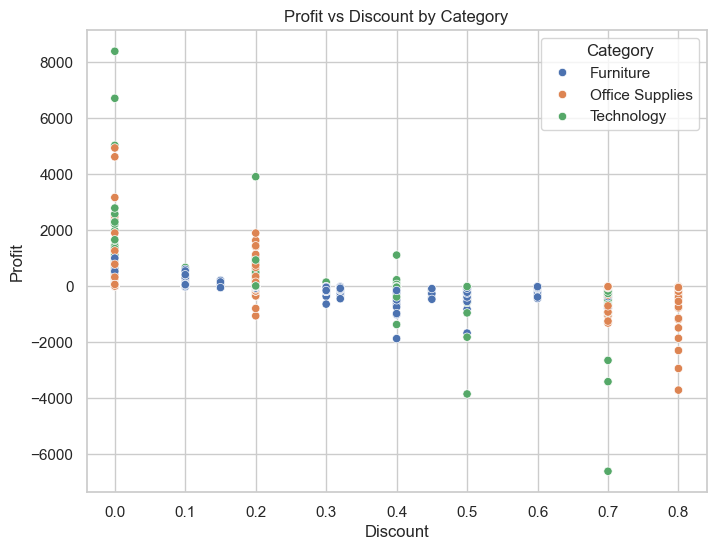

In [27]:
plt.figure(figsize=(8,6))
sns.scatterplot(data=df, x='Discount', y='Profit', hue='Category')
plt.title("Profit vs Discount by Category")
plt.show()


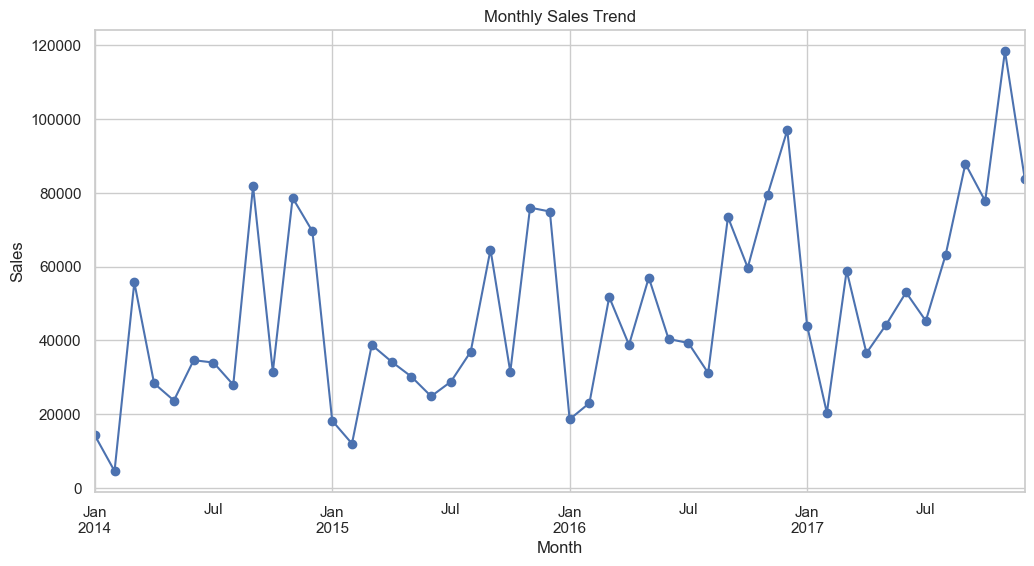

In [29]:
df['Month'] = df['Order Date'].dt.to_period('M')
monthly_sales = df.groupby('Month')['Sales'].sum()

plt.figure(figsize=(12,6))
monthly_sales.plot(kind='line', marker='o')
plt.title("Monthly Sales Trend")
plt.ylabel("Sales")
plt.xlabel("Month")
plt.grid(True)
plt.show()


In [10]:
import pandas as pd

# Load the cleaned data
df = pd.read_csv(
    r"C:\Users\Dell\OneDrive\Documents\Projects\sales_dashboard_superstore\data\clean\superstore_clean.csv",
    encoding='latin1',
    parse_dates=['Order Date', 'Ship Date']
)

# 💰 Total Sales
total_sales = df['Sales'].sum()

# 📈 Total Profit
total_profit = df['Profit'].sum()

# 📦 Total Orders (unique order IDs)
total_orders = df['Order ID'].nunique()

# 💸 Average Discount (%)
avg_discount = df['Discount'].mean() * 100

# Display the results neatly
print("===== KPI Metrics (Cross-Check) =====")
print(f"💰 Total Sales        : ₹ {total_sales:,.2f}")
print(f"📈 Total Profit       : ₹ {total_profit:,.2f}")
print(f"📦 Total Orders       : {total_orders:,}")
print(f"💸 Avg Discount (%)   : {avg_discount:.2f}%")


===== KPI Metrics (Cross-Check) =====
💰 Total Sales        : ₹ 2,297,200.86
📈 Total Profit       : ₹ 286,397.02
📦 Total Orders       : 5,009
💸 Avg Discount (%)   : 15.62%
